#Exploring Campaign Expenditures and Election Outcomes in North Carolina

This notebook presents an analysis of campaign expenditures and congressional race results in North Carolina. The data used in this study is sourced from the Federal Election Commission (FEC) and the North Carolina State Board of Elections. Our goal is to understand the impact of campaign spending on election outcomes and provide insights that could guide future campaign strategies.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np #Numpy
import pandas as pd #Pandas
import matplotlib.pyplot as plt #Plotly
import seaborn as sns #Seaborn

In [ ]:
#Load the data for each candidate
holding = pd.read_csv('/content/drive/MyDrive/Dataset/George Holding for Congress.csv')
matemu = pd.read_csv('/content/drive/MyDrive/Dataset/Jeff Matemu for Congress.csv')
coleman = pd.read_csv('/content/drive/MyDrive/Dataset/Linda Coleman for Congress.csv')


# Combine the data from all three candidates into a single DataFrame
# This will make it easier to analyze the data for all candidates together
all_parties_data = pd.concat([holding, matemu, coleman])


# Display the first few rows of the combined data
# This is a good way to quickly check whether the data has been loaded and combined correctly
all_parties_data.head()


,committee_id,committee_name,report_year,report_type,image_number,line_number,transaction_id,file_number,committee_name.1,entity_type,...,filing_form,link_id,is_individual,memo_text,two_year_transaction_period,schedule_type,increased_limit,sub_id,pdf_url,line_number_label
0,C00499236,GEORGE HOLDING FOR CONGRESS INC.,2018,30G,201812069134454593,11AI,SA11AI-CN155121,1297340,NaN,IND,...,F3,4120620181620449804,t,REATTRIBUTED,2018,SA,NaN,4020520191637918782,http://docquery.fec.gov/cgi-bin/fecimg/?201812...,Contributions From Individuals/Persons Other T...
1,C00499236,GEORGE HOLDING FOR CONGRESS INC.,2018,30G,201812069134454565,11AI,SA11AI-CN154734,1297340,NaN,IND,...,F3,4120620181620449804,t,REATTRIBUTED,2018,SA,NaN,4020520191637918699,http://docquery.fec.gov/cgi-bin/fecimg/?201812...,Contributions From Individuals/Persons Other T...
2,C00499236,GEORGE HOLDING FOR CONGRESS INC.,2018,Q1,201804139108029564,11AI,SA11AI-CN118598,1220743,NaN,IND,...,F3,4041320181525847718,t,REATTRIBUTED,2018,SA,NaN,4042420181526528894,http://docquery.fec.gov/cgi-bin/fecimg/?201804...,Contributions From Individuals/Persons Other T...
3,C00499236,GEORGE HOLDING FOR CONGRESS INC.,2018,Q1,201804139108029549,11AI,SA11AI-CN118672,1220743,NaN,IND,...,F3,4041320181525847718,t,NaN,2018,SA,NaN,4042420181526528806,http://docquery.fec.gov/cgi-bin/fecimg/?201804...,Contributions From Individuals/Persons Other T...
4,C00499236,GEORGE HOLDING FOR CONGRESS INC.,2018,12G,201810259131060724,11AI,SA11AI-CN152714,1282930,NaN,IND,...,F3,4102520181600641538,t,REATTRIBUTED,2018,SA,NaN,4111420181617594082,http://docquery.fec.gov/cgi-bin/fecimg/?201810...,Contributions From Individuals/Persons Other T...


## Initial Data Exploration

In [ ]:
holding.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2266 entries, 0 to 2265
Data columns (total 79 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   committee_id                           2266 non-null   object        
 1   committee_name                         2266 non-null   object        
 2   report_year                            2266 non-null   int64         
 3   report_type                            2266 non-null   object        
 4   image_number                           2266 non-null   int64         
 5   line_number                            2266 non-null   object        
 6   transaction_id                         2266 non-null   object        
 7   file_number                            2266 non-null   int64         
 8   committee_name.1                       0 non-null      float64       
 9   entity_type                            2266 non-null   object  

##  Data Cleaning

In the data cleaning phase of my analysis, I encountered several outliers that could potentially skew the results. To ensure the accuracy of my findings, I decided to remove these outliers from the dataset.

The first step in this process was to drop unnecessary columns from the DataFrame. The columns ‘conduit_committee_name’, ‘conduit_committee_city’, and ‘election_type_full’ were dropped as they were not relevant to my analysis. This was done using the drop method in pandas, which allows for the removal of specified labels from rows or columns.

In [ ]:
all_parties_data.drop(['conduit_committee_name', 'conduit_committee_city', 'election_type_full'], axis= 1, inplace= True)

# Generate descriptive statistics of the DataFrame
statistics = all_parties_data.describe()

# Display the selected statistics
print(statistics)

       report_year  image_number   file_number  committee_name.1  \
count  5680.000000  5.680000e+03  5.680000e+03               0.0   
mean   2017.857042  2.018226e+17  1.275750e+06               NaN   
std       0.350061  5.551521e+13  5.877493e+04               NaN   
min    2017.000000  2.017041e+17  1.157179e+06               NaN   
25%    2018.000000  2.018071e+17  1.246068e+06               NaN   
50%    2018.000000  2.018102e+17  1.270930e+06               NaN   
75%    2018.000000  2.018121e+17  1.297340e+06               NaN   
max    2018.000000  2.019121e+17  1.365684e+06               NaN   

       contribution_receipt_amount  contributor_aggregate_ytd  \
count                  5680.000000                5680.000000   
mean                    857.590285               60204.199280   
std                    1575.590384              130629.958703   
min                   -2700.000000               -1000.000000   
25%                     150.000000                 500.000000 

After cleaning the data, I generated descriptive statistics of the DataFrame using the describe method. This provided me with a summary of the central tendency, dispersion, and shape of the dataset’s distribution. By examining these statistics, I was able to gain a deeper understanding of my data and ensure that it was properly cleaned and ready for further analysis.

## Data Visualization

In [ ]:
# Convert 'contribution_receipt_date' from string to datetime format for each DataFrame
# This allows for more efficient and accurate analysis and manipulation of date-time values later in the analysis
holding['contribution_receipt_date'] = pd.to_datetime(holding['contribution_receipt_date'])
matemu['contribution_receipt_date'] = pd.to_datetime(matemu['contribution_receipt_date'])
coleman['contribution_receipt_date'] = pd.to_datetime(coleman['contribution_receipt_date'])

In [ ]:
# Group the data by month and calculate the total contribution receipt amount for each month
# This provides a time series of monthly campaign contributions
holding_mm = holding.groupby(holding.contribution_receipt_date.dt.to_period('M'))['contribution_receipt_amount'].sum()
matemu_mm = matemu.groupby(matemu.contribution_receipt_date.dt.to_period('M'))['contribution_receipt_amount'].sum()
coleman_mm = coleman.groupby(coleman.contribution_receipt_date.dt.to_period('M'))['contribution_receipt_amount'].sum()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, '2017-01'),
  Text(1, 0, '2017-02'),
  Text(2, 0, '2017-03'),
  Text(3, 0, '2017-04'),
  Text(4, 0, '2017-05'),
  Text(5, 0, '2017-06'),
  Text(6, 0, '2017-07'),
  Text(7, 0, '2017-08'),
  Text(8, 0, '2017-09'),
  Text(9, 0, '2017-10'),
  Text(10, 0, '2017-11'),
  Text(11, 0, '2017-12'),
  Text(12, 0, '2018-01'),
  Text(13, 0, '2018-02'),
  Text(14, 0, '2018-03'),
  Text(15, 0, '2018-04'),
  Text(16, 0, '2018-05'),
  Text(17, 0, '2018-06'),
  Text(18, 0, '2018-07'),
  Text(19, 0, '2018-08'),
  Text(20, 0, '2018-09'),
  Text(21, 0, '2018-10'),
  Text(22, 0, '2018-11'),
  Text(23, 0, '2018-12')])

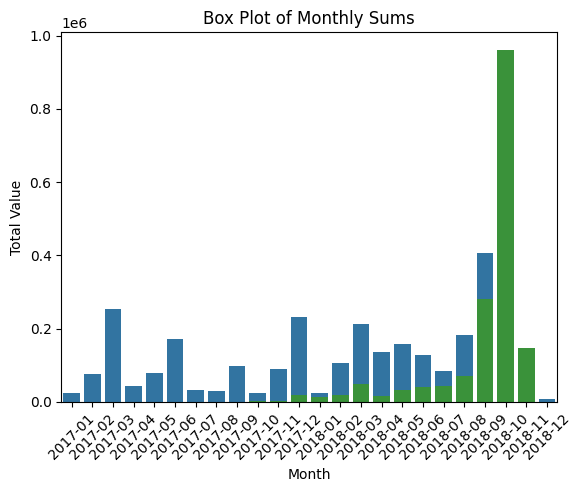

In [ ]:
# Create bar plots for the monthly total contribution receipt amount for each candidate
# This provides a visual representation of the monthly campaign contributions
sns.barplot(holding_mm)
sns.barplot(matemu_mm)
sns.barplot(coleman_mm)
plt.title('Box Plot of Monthly Sums')
plt.xlabel('Month')
plt.ylabel('Total Value')
plt.xticks(rotation=45)

<ipython-input-110-8aa29f039e6b>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  holding_sept.sort_values(by='contribution_receipt_date', inplace=True)


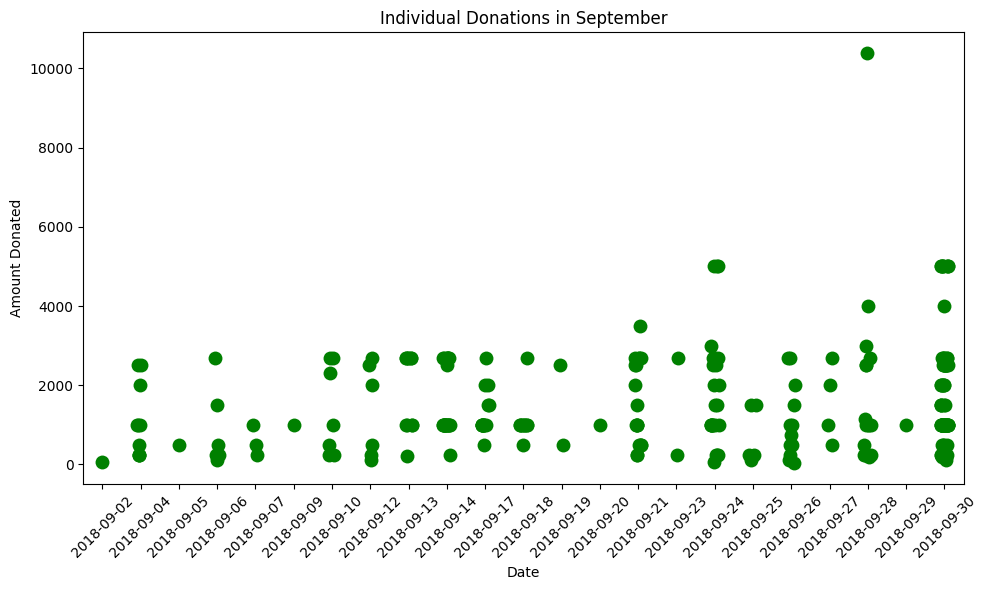

In [ ]:
# Filter the 'holding' DataFrame for contributions made in September 2018
holding_sept = holding[(holding['contribution_receipt_date'].dt.year == 2018) & (holding['contribution_receipt_date'].dt.month == 9)]

# Sort the filtered data by 'contribution_receipt_date'
holding_sept.sort_values(by='contribution_receipt_date', inplace=True)

# Create a new figure with a specified size
plt.figure(figsize=(10, 6))

# Create a strip plot of individual donations made in September
# 'jitter=True' spreads out overlapping points for better visibility
# 'size=10' sets the size of the points
sns.stripplot(data=holding_sept, y='contribution_receipt_amount', x='contribution_receipt_date', color='green', jitter=True, size=10)

# Add labels and title to the plot
plt.xlabel('Date')
plt.ylabel('Amount Donated')
plt.title('Individual Donations in September')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust the layout to fit the plot within the figure area
plt.tight_layout()

# Display the plot
plt.show()

<ipython-input-89-38681cbd9cd8>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matemu_sept.sort_values(by='contribution_receipt_date', inplace=True)


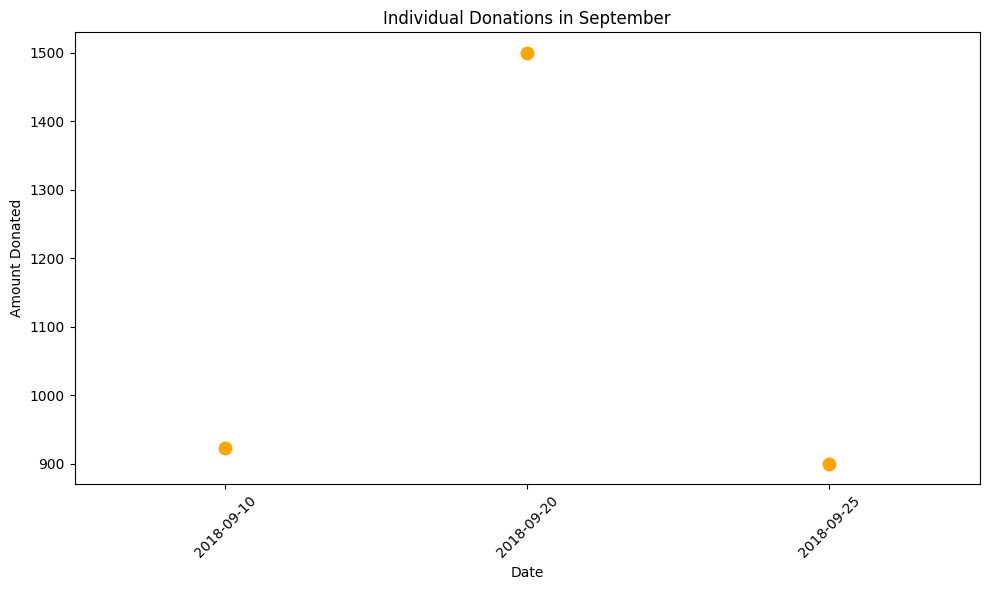

In [ ]:
# Filter the 'matemu' DataFrame for contributions made in September 2018
matemu_sept = matemu[(matemu['contribution_receipt_date'].dt.year == 2018) & (matemu['contribution_receipt_date'].dt.month == 9)]

# Sort the filtered data by 'contribution_receipt_date'
matemu_sept.sort_values(by='contribution_receipt_date', inplace=True)

# Create a new figure with a specified size
plt.figure(figsize=(10, 6))

# Create a strip plot of individual donations made in September
# 'jitter=True' spreads out overlapping points for better visibility
# 'size=10' sets the size of the points
sns.stripplot(data=matemu_sept, y='contribution_receipt_amount', x='contribution_receipt_date', color='orange', jitter=True, size=10)

# Add labels and title to the plot
plt.xlabel('Date')
plt.ylabel('Amount Donated')
plt.title('Individual Donations in September')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust the layout to fit the plot within the figure area
plt.tight_layout()

# Display the plot
plt.show()


<ipython-input-90-4946f7c746c6>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coleman_sept.sort_values(by='contribution_receipt_date', inplace=True)


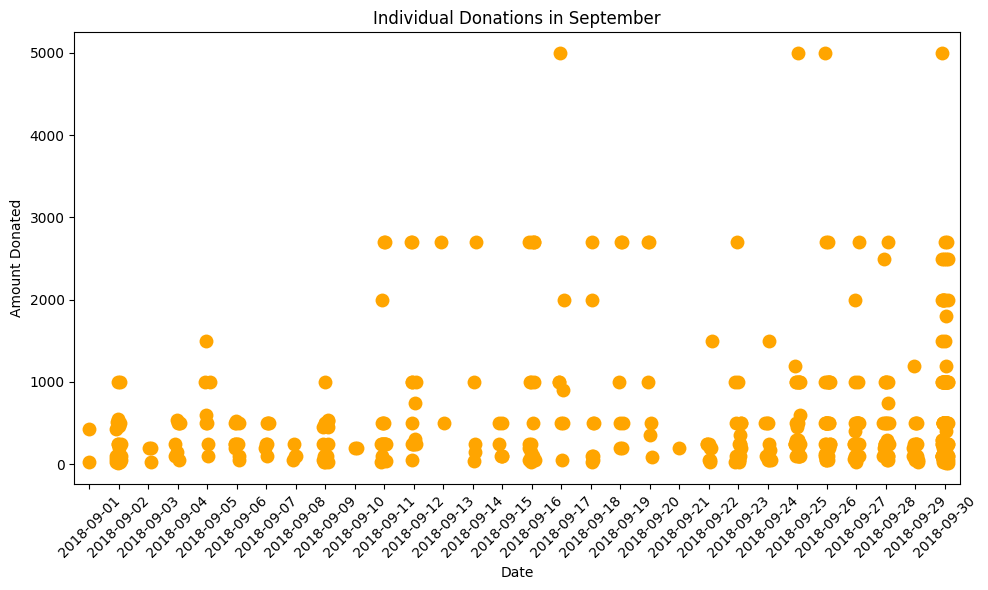

In [ ]:
# Filter the 'coleman' DataFrame for contributions made in September 2018
coleman_sept = coleman[(coleman['contribution_receipt_date'].dt.year == 2018) & (coleman['contribution_receipt_date'].dt.month == 9)]

# Sort the filtered data by 'contribution_receipt_date'
coleman_sept.sort_values(by='contribution_receipt_date', inplace=True)

# Create a new figure with a specified size
plt.figure(figsize=(10, 6))

# Create a strip plot of individual donations made in September
# 'jitter=True' spreads out overlapping points for better visibility
# 'size=10' sets the size of the points
sns.stripplot(data=coleman_sept, y='contribution_receipt_amount', x='contribution_receipt_date', color='orange', jitter=True, size=10)

# Add labels and title to the plot
plt.xlabel('Date')
plt.ylabel('Amount Donated')
plt.title('Individual Donations in September')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust the layout to fit the plot within the figure area
plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
# Combine the September donation data for all three candidates into a single DataFrame
# This allows for easier comparison and analysis of the donation data across all candidates
sept_donations = pd.concat([holding_sept, matemu_sept, coleman_sept])

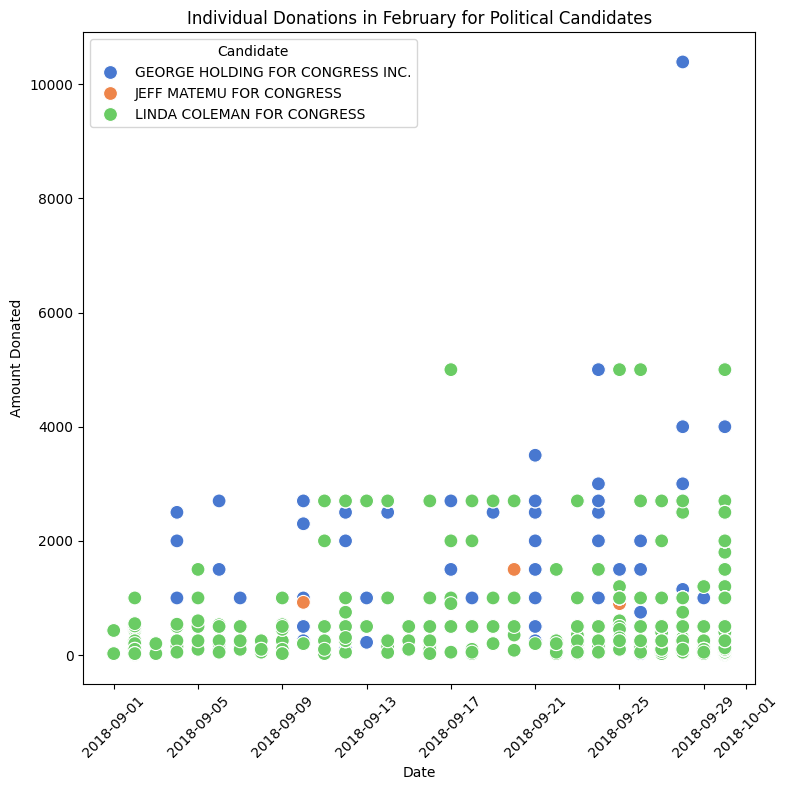

In [ ]:
# Combine the September donation data for all three candidates into a single DataFrame
# This allows for easier comparison and analysis of the donation data across all candidates
sept_donations = pd.concat([holding_sept, matemu_sept, coleman_sept])

# Create a new figure with a specified size
plt.figure(figsize=(8, 8))

# Create a scatter plot of individual donations made in September
# 'hue' parameter is used to color the points according to the 'committee_name'
# 'palette' parameter is used to set the colors of the different categories in 'hue'
# 's' parameter sets the size of the points in the plot
sns.scatterplot(data=sept_donations, x='contribution_receipt_date', y='contribution_receipt_amount', hue='committee_name', palette='muted', s=100)

# Add labels and title to the plot
plt.xlabel('Date')
plt.ylabel('Amount Donated')
plt.title('Individual Donations in September for Political Candidates')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add a legend to the plot with a title
plt.legend(title='Candidate')

# Adjust the layout to fit the plot within the figure area
plt.tight_layout()

# Display the plot
plt.show()


In my data analysis project, I’ve implemented several key steps. I’ve loaded my data into pandas DataFrames using pd.read_csv(), and merged data from multiple DataFrames into one using pd.concat(). I’ve converted the ‘contribution_receipt_date’ column in my DataFrames from a string format to a datetime format using pd.to_datetime(), which allows for more efficient and accurate analysis and manipulation of date-time values. I’ve grouped my data by month and calculated each month’s total contribution receipt amount using the groupby() function, providing a time series of monthly campaign contributions. I’ve sorted my data by ‘contribution_receipt_date’ using the sort_values() function to ensure the correct order when plotting. For data visualization, I’ve used sns.barplot(), sns.stripplot(), and sns.scatterplot() functions from the seaborn library to create various plots. Lastly, I’ve adjusted the size and layout of my figures, and rotated the x-axis labels for better readability using plt.figure(), plt.xticks(), and plt.tight_layout() functions from the matplotlib library. These methods form the core of my data analysis workflow, allowing me to load, preprocess, analyze, and visualize my data effectively.

During my data analysis project, I met many problems. One of the most important was deciding which columns to keep and which to eliminate when collecting the data. The sheer volume of the data made it difficult to determine the relevance of each column at first look. However, I addressed this difficulty by completing a thorough exploratory data analysis (EDA). This procedure entailed analyzing summary statistics, displaying distributions, and determining relationships between variables. This comprehensive analysis allowed me to grasp the data better and make informed conclusions about which columns were required for my study.






